In [41]:
# ============================================================
# TASK 3 — EDA SETUP & DATA LOADING
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. PROJECT PATH
# ------------------------------------------------------------

ROOT = Path(r"C:\Users\drdee\Desktop\BlueStock_fintech\capstone_project")

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
OUTPUTS = ROOT / "outputs"

OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Processed folder:", PROCESSED)
print("Processed folder exists:", PROCESSED.exists())

# ------------------------------------------------------------
# 2. CHECK PROCESSED FILES
# ------------------------------------------------------------

csv_files = list(PROCESSED.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in:\n{PROCESSED}\n\n"
        "Please check that your data is inside data/processed/"
    )

print("\nCSV files found:")
for f in csv_files:
    print("  ✓", f.name)

# ------------------------------------------------------------
# 3. FLEXIBLE CSV LOADER
#    Finds files using the dataset number/name even when
#    the filename has generated prefixes.
# ------------------------------------------------------------

def load_dataset(identifier):
    """
    Load a CSV from processed/ using a partial filename match.

    Example:
        load_dataset("01_fund_master")
        load_dataset("02_nav_history")
    """

    # Search processed first
    matches = list(PROCESSED.glob(f"*{identifier}*.csv"))

    # If not found, search raw
    if not matches:
        matches = list(RAW.glob(f"*{identifier}*.csv"))

    if not matches:
        raise FileNotFoundError(
            f"Could not find dataset containing '{identifier}'.\n\n"
            f"Processed folder: {PROCESSED}\n"
            f"Raw folder: {RAW}"
        )

    if len(matches) > 1:
        print(f"Multiple matches found for {identifier}:")
        for m in matches:
            print(" ", m.name)
        print("Using:", matches[0].name)

    path = matches[0]

    print(f"Loading: {path.name}")

    df = pd.read_csv(path)

    print(f"  → {len(df):,} rows × {len(df.columns)} columns")

    return df

# ------------------------------------------------------------
# 4. LOAD ALL DATASETS
# ------------------------------------------------------------

fund = load_dataset("01_fund_master")

nav = load_dataset("02_nav_history")

aum = load_dataset("03_aum_by_fund_house")

sip = load_dataset("04_monthly_sip_inflows")

folio = load_dataset("06_industry_folio_count")

perf = load_dataset("07_scheme_performance")

tx = load_dataset("08_investor_transactions")

hold = load_dataset("09_portfolio_holdings")

bench = load_dataset("10_benchmark_indices")

# ------------------------------------------------------------
# 5. BASIC CLEANING
# ------------------------------------------------------------

datasets = {
    "fund": fund,
    "nav": nav,
    "aum": aum,
    "sip": sip,
    "folio": folio,
    "perf": perf,
    "tx": tx,
    "hold": hold,
    "bench": bench
}

for name, df in datasets.items():

    # Normalize column names
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

    # Strip whitespace from string columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

# ------------------------------------------------------------
# 6. CONVERT DATE COLUMNS
# ------------------------------------------------------------

date_columns = {
    "nav": ["date"],
    "aum": ["report_date", "date"],
    "sip": ["month", "date"],
    "folio": ["month", "date"],
    "tx": ["transaction_date", "date"],
    "bench": ["date"],
    "fund": ["inception_date"]
}

for dataset_name, possible_columns in date_columns.items():

    df = datasets[dataset_name]

    for col in possible_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

# ------------------------------------------------------------
# 7. PRINT DATASET SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

for name, df in datasets.items():
    print(
        f"{name:10s} : "
        f"{len(df):>8,} rows × "
        f"{len(df.columns):>3} columns"
    )

# ------------------------------------------------------------
# 8. SHOW COLUMN NAMES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(list(df.columns))

print("\n✓ All datasets loaded successfully.")

Project root: C:\Users\drdee\Desktop\BlueStock_fintech\capstone_project
Processed folder: C:\Users\drdee\Desktop\BlueStock_fintech\capstone_project\data\processed
Processed folder exists: True

CSV files found:
  ✓ 1788499980509-304c1255-08_investor_transactions.csv
  ✓ 1788499982117-e3d6ab98-09_portfolio_holdings.csv
  ✓ 1788499982615-f9647ab2-10_benchmark_indices.csv
  ✓ 1788499983024-b042c300-01_fund_master.csv
  ✓ 1788499983331-4389156d-02_nav_history.csv
  ✓ 1788499984134-b0cbf625-03_aum_by_fund_house.csv
  ✓ 1788499984405-d702a6c6-04_monthly_sip_inflows.csv
  ✓ 1788499985036-da4a0c4a-06_industry_folio_count.csv
  ✓ 1788499985420-bb134abf-07_scheme_performance.csv
  ✓ data_quality_report.csv
Loading: 1788499983024-b042c300-01_fund_master.csv
  → 40 rows × 15 columns
Loading: 1788499983331-4389156d-02_nav_history.csv
  → 46,000 rows × 3 columns
Loading: 1788499984134-b0cbf625-03_aum_by_fund_house.csv
  → 90 rows × 5 columns
Loading: 1788499984405-d702a6c6-04_monthly_sip_inflows.csv

In [42]:
# Chart 1 — all scheme NAV trends
nav_plot = nav.copy()
nav_plot["date"] = pd.to_datetime(nav_plot["date"])
nav_plot = nav_plot.merge(fund[["amfi_code","scheme_name"]], on="amfi_code", how="left")

fig = px.line(
    nav_plot, x="date", y="nav", color="scheme_name",
    title="Daily NAV Trends — 40 Mutual Fund Schemes (2022–2026)",
    labels={"nav":"NAV (₹)", "date":"Date", "scheme_name":"Scheme"}
)
fig.update_layout(height=700, legend_title_text="Scheme")
fig.show()


In [43]:
indexed["date"] = pd.to_datetime(indexed["date"])

indexed["indexed_nav"] = indexed.groupby("amfi_code")["nav"].transform(
    lambda s: s / s.iloc[0] * 100
)

fig = px.line(
    indexed,
    x="date",
    y="indexed_nav",
    color="scheme_name",
    title="Indexed NAV Performance — Base = 100",
    labels={
        "indexed_nav": "Indexed NAV",
        "date": "Date"
    }
)

fig.add_shape(
    type="line",
    x0="2023-01-01", x1="2023-01-01",
    y0=0, y1=1,
    xref="x", yref="paper",
    line=dict(dash="dash")
)

fig.add_shape(
    type="line",
    x0="2024-01-01", x1="2024-01-01",
    y0=0, y1=1,
    xref="x", yref="paper",
    line=dict(dash="dash")
)

fig.show()

In [44]:
# Chart 3 — representative scheme NAVs with market-period markers
sample_codes = fund["amfi_code"].head(8).tolist()
sample = nav_plot[nav_plot["amfi_code"].isin(sample_codes)]
fig = px.line(sample, x="date", y="nav", color="scheme_name",
              title="Representative Scheme NAV Trends")
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", opacity=0.08, line_width=0,
              annotation_text="2023")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", opacity=0.08, line_width=0,
              annotation_text="2024")
fig.show()


AUM columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

Detected columns:
Date column      : date
Fund house column: fund_house
AUM column       : aum_crore

AUM yearly summary:


,year,fund_house,aum_crore
0,2022,Aditya Birla Sun Life MF,563000
1,2022,Axis Mutual Fund,490000
2,2022,DSP Mutual Fund,222000
3,2022,HDFC Mutual Fund,880000
4,2022,ICICI Prudential MF,953000
5,2022,Kotak Mahindra MF,542000
6,2022,Mirae Asset MF,213000
7,2022,Nippon India MF,548000
8,2022,SBI Mutual Fund,1235000
9,2022,UTI Mutual Fund,462000


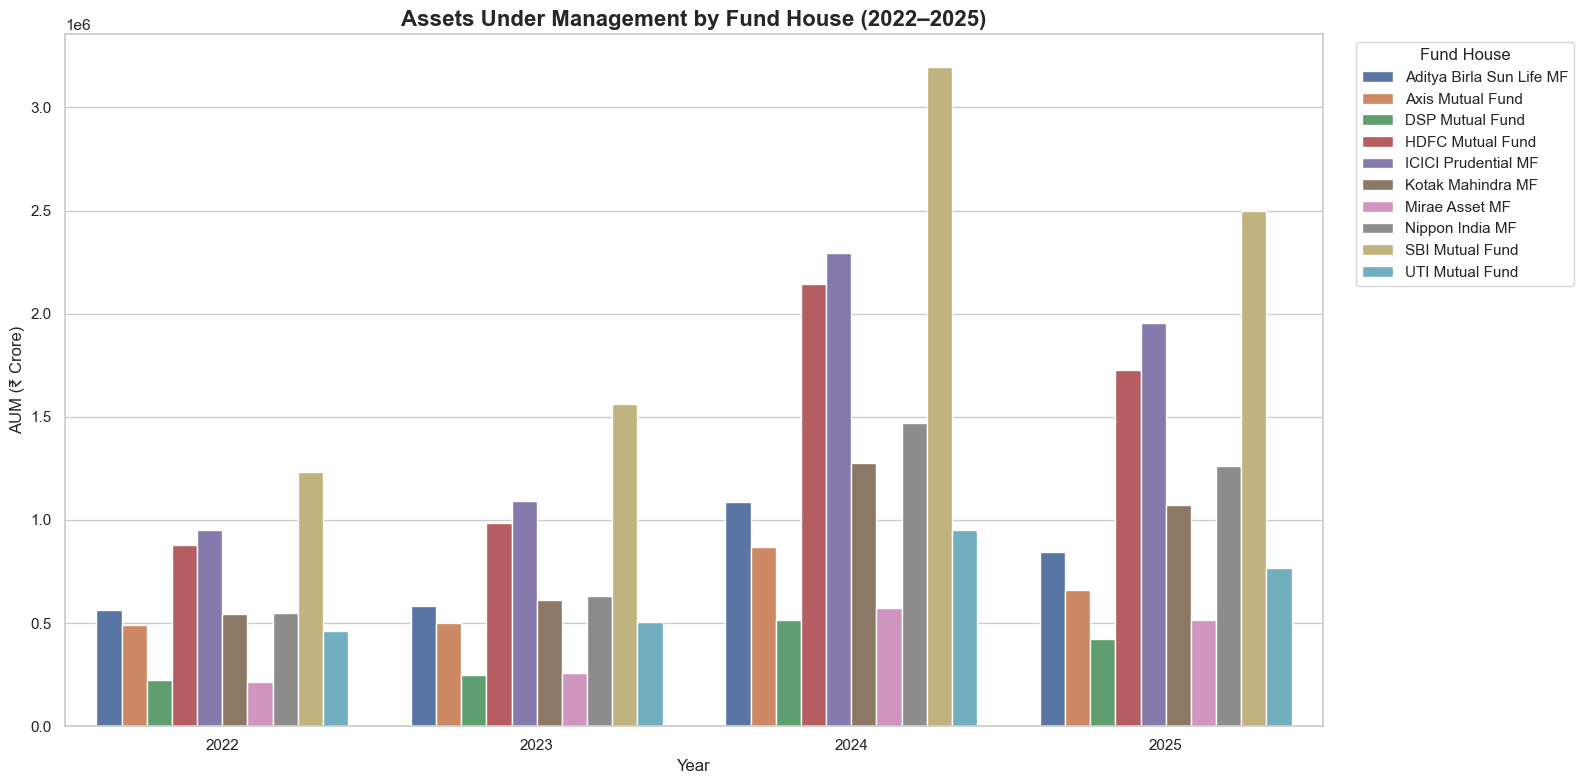


✓ AUM analysis completed successfully.
Chart saved to: C:\Users\drdee\Desktop\BlueStock_fintech\capstone_project\outputs\aum_by_fund_house_year.png


In [45]:
# ============================================================
# AUM BY FUND HOUSE — YEARLY ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. CHECK ACTUAL COLUMNS
# ------------------------------------------------------------

print("AUM columns:")
print(aum.columns.tolist())

# ------------------------------------------------------------
# 2. FIND DATE COLUMN
# ------------------------------------------------------------

date_candidates = [
    "report_date",
    "date",
    "month",
    "reporting_date",
    "as_of_date"
]

date_col = None

for col in date_candidates:
    if col in aum.columns:
        date_col = col
        break

if date_col is None:
    raise KeyError(
        "\nNo date column found in AUM dataset.\n"
        f"Available columns: {aum.columns.tolist()}"
    )

# Convert date
aum[date_col] = pd.to_datetime(
    aum[date_col],
    errors="coerce"
)

# Remove invalid dates
aum = aum.dropna(subset=[date_col]).copy()

# Create year
aum["year"] = aum[date_col].dt.year

# ------------------------------------------------------------
# 3. FIND FUND HOUSE COLUMN
# ------------------------------------------------------------

fund_house_candidates = [
    "fund_house",
    "amc",
    "fund_house_name",
    "amc_name"
]

fund_house_col = None

for col in fund_house_candidates:
    if col in aum.columns:
        fund_house_col = col
        break

if fund_house_col is None:
    raise KeyError(
        "\nNo fund-house column found.\n"
        f"Available columns: {aum.columns.tolist()}"
    )

# ------------------------------------------------------------
# 4. FIND AUM COLUMN
# ------------------------------------------------------------

aum_candidates = [
    "aum_crore",
    "aum",
    "aum_cr",
    "aum_in_crore",
    "aum_inr_crore"
]

aum_col = None

for col in aum_candidates:
    if col in aum.columns:
        aum_col = col
        break

if aum_col is None:
    raise KeyError(
        "\nNo AUM column found.\n"
        f"Available columns: {aum.columns.tolist()}"
    )

# Convert AUM to numeric
aum[aum_col] = pd.to_numeric(
    aum[aum_col],
    errors="coerce"
)

# Remove invalid AUM values
aum = aum.dropna(subset=[aum_col]).copy()

# ------------------------------------------------------------
# 5. FILTER REQUIRED YEARS
# ------------------------------------------------------------

aum_filtered = aum[
    aum["year"].between(2022, 2025)
].copy()

# ------------------------------------------------------------
# 6. AGGREGATE AUM BY FUND HOUSE AND YEAR
# ------------------------------------------------------------

aum_yearly = (
    aum_filtered
    .groupby(["year", fund_house_col], as_index=False)[aum_col]
    .sum()
)

# ------------------------------------------------------------
# 7. DISPLAY DATA
# ------------------------------------------------------------

print("\nDetected columns:")
print("Date column      :", date_col)
print("Fund house column:", fund_house_col)
print("AUM column       :", aum_col)

print("\nAUM yearly summary:")
display(aum_yearly.head(20))

# ------------------------------------------------------------
# 8. CREATE BAR CHART
# ------------------------------------------------------------

plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_yearly,
    x="year",
    y=aum_col,
    hue=fund_house_col
)

plt.title(
    "Assets Under Management by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")

plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# ------------------------------------------------------------
# 9. SAVE CHART
# ------------------------------------------------------------

OUTPUTS.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    OUTPUTS / "aum_by_fund_house_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ AUM analysis completed successfully.")
print(
    "Chart saved to:",
    OUTPUTS / "aum_by_fund_house_year.png"
)

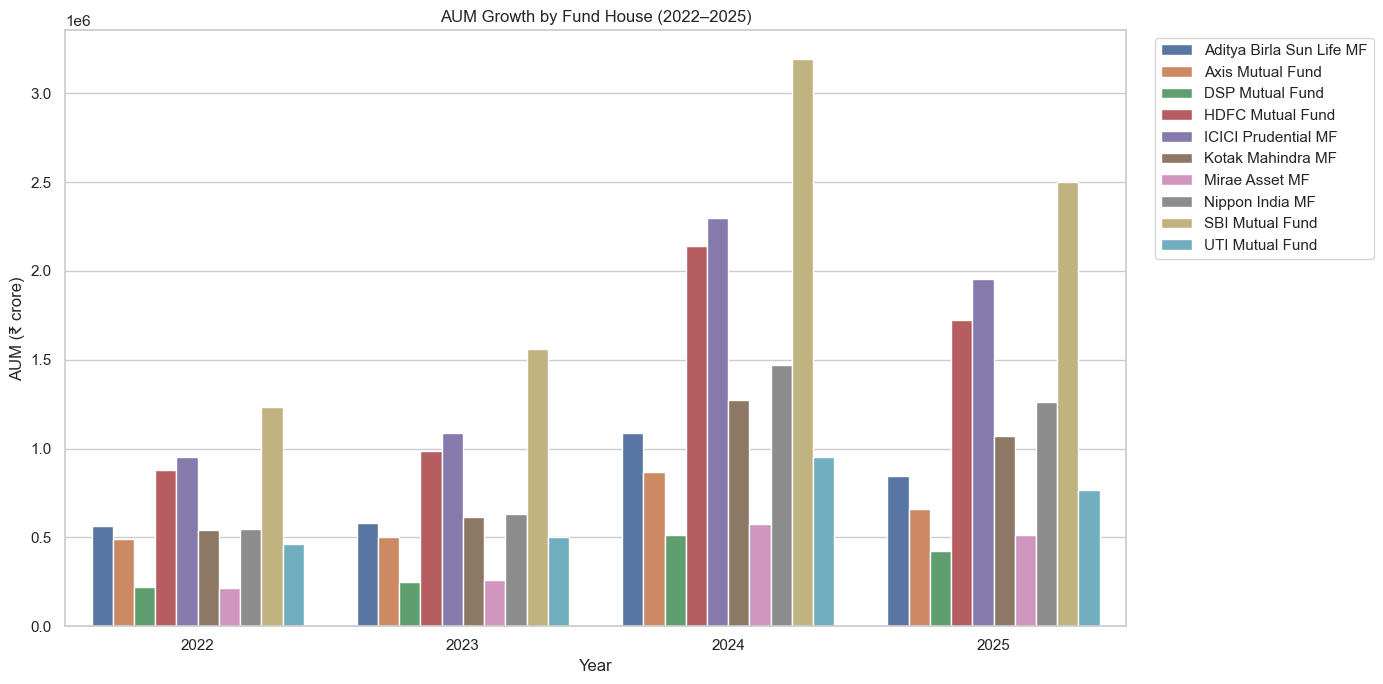

In [46]:
# Chart 4 — grouped AUM by fund house/year
house_col = "fund_house"
aum_value = "aum_crore"
if house_col not in aum.columns:
    house_col = [c for c in aum.columns if "house" in c][0]
if aum_value not in aum.columns:
    aum_value = [c for c in aum.columns if "aum" in c.lower()][0]

g = aum.groupby(["year", house_col], as_index=False)[aum_value].sum()
plt.figure(figsize=(14,7))
sns.barplot(data=g, x="year", y=aum_value, hue=house_col)
plt.title("AUM Growth by Fund House (2022–2025)")
plt.ylabel("AUM (₹ crore)")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUTS / "04_aum_growth_by_fund_house.png", dpi=200, bbox_inches="tight")
plt.show()


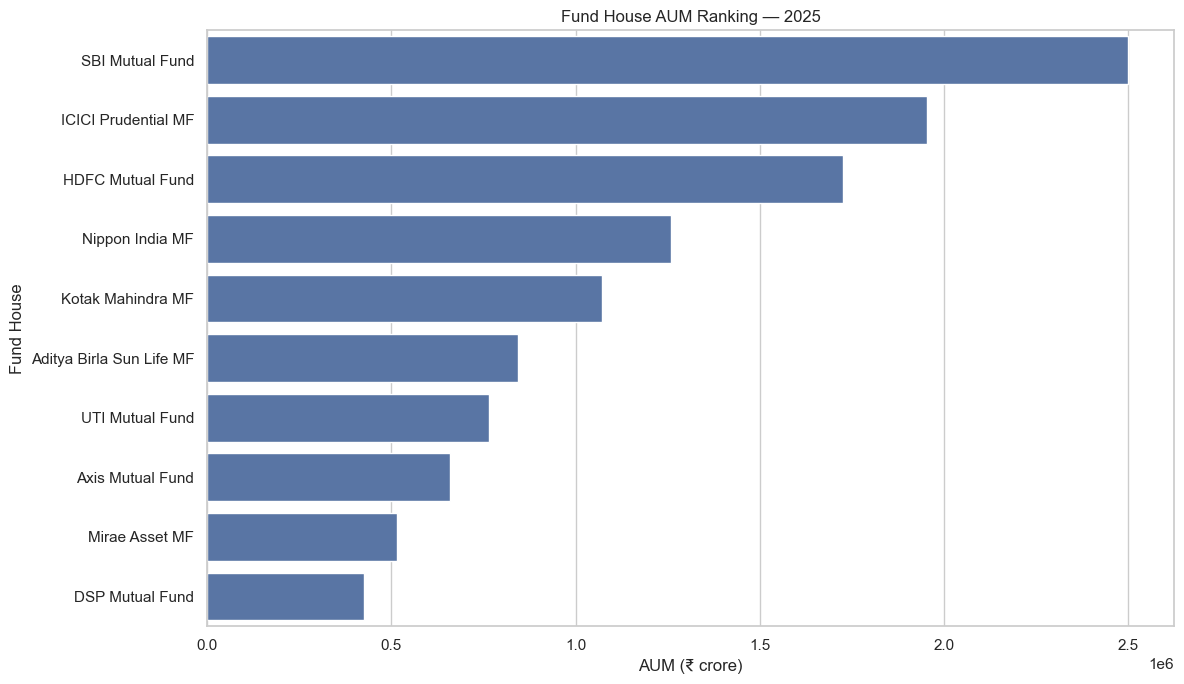

In [47]:
# Chart 5 — year-end AUM ranking
latest_year = g["year"].max()
latest_aum = g[g["year"] == latest_year].sort_values(aum_value, ascending=False)
plt.figure(figsize=(12,7))
sns.barplot(data=latest_aum, y=house_col, x=aum_value)
plt.title(f"Fund House AUM Ranking — {latest_year}")
plt.xlabel("AUM (₹ crore)")
plt.ylabel("Fund House")
plt.tight_layout()
plt.savefig(OUTPUTS / "05_latest_aum_ranking.png", dpi=200, bbox_inches="tight")
plt.show()


In [48]:
sip["month"] = pd.to_datetime(sip["month"])
sip_value = "sip_inflow_crore"
if sip_value not in sip.columns:
    sip_value = [c for c in sip.columns if "sip" in c.lower() and "inflow" in c.lower()][0]
peak = sip.loc[sip[sip_value].idxmax()]
fig = px.line(sip, x="month", y=sip_value,
              title="Monthly SIP Inflows — Jan 2022 to Dec 2025",
              labels={sip_value:"SIP inflow (₹ crore)", "month":"Month"})
fig.add_scatter(x=[peak["month"]], y=[peak[sip_value]], mode="markers+text",
                text=[f"Peak: ₹{peak[sip_value]:,.0f} Cr"], textposition="top center",
                name="All-time high")
fig.show()


In [49]:
# Chart 7 — SIP inflow with rolling 12-month average
sip2 = sip.sort_values("month").copy()
sip2["rolling_12m"] = sip2[sip_value].rolling(12).mean()
fig = px.line(sip2, x="month", y=[sip_value,"rolling_12m"],
              title="SIP Inflows with 12-Month Rolling Average",
              labels={"value":"₹ crore","variable":"Series","month":"Month"})
fig.show()


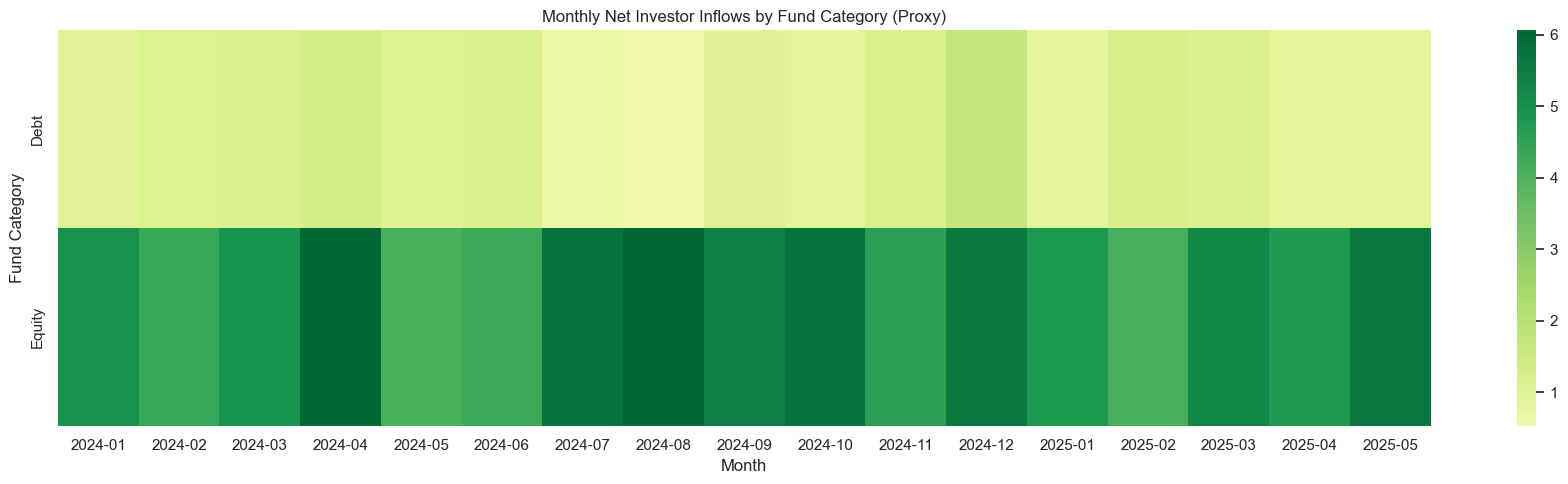

In [50]:
# Missing category_inflows.csv workaround:
# derive monthly net investor transaction inflow by fund category.
tx["transaction_date"] = pd.to_datetime(tx["transaction_date"])
tx2 = tx.merge(fund[["amfi_code","category"]], on="amfi_code", how="left")
sign = {"SIP": 1, "Lumpsum": 1, "Redemption": -1}
tx2["signed_amount"] = tx2["transaction_type"].map(sign).fillna(0) * tx2["amount_inr"]
tx2["month"] = tx2["transaction_date"].dt.to_period("M").astype(str)

cat_month = tx2.groupby(["category","month"], as_index=False)["signed_amount"].sum()
heat = cat_month.pivot(index="category", columns="month", values="signed_amount").fillna(0)

plt.figure(figsize=(18,5))
sns.heatmap(heat / 1e7, cmap="RdYlGn", center=0)
plt.title("Monthly Net Investor Inflows by Fund Category (Proxy)")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()
plt.savefig(OUTPUTS / "08_category_net_inflow_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


In [51]:
# Chart 9 — age-group distribution
age_counts = tx["age_group"].value_counts().reset_index()
age_counts.columns = ["age_group","transactions"]
fig = px.pie(age_counts, names="age_group", values="transactions",
             title="Investor Transaction Distribution by Age Group")
fig.show()


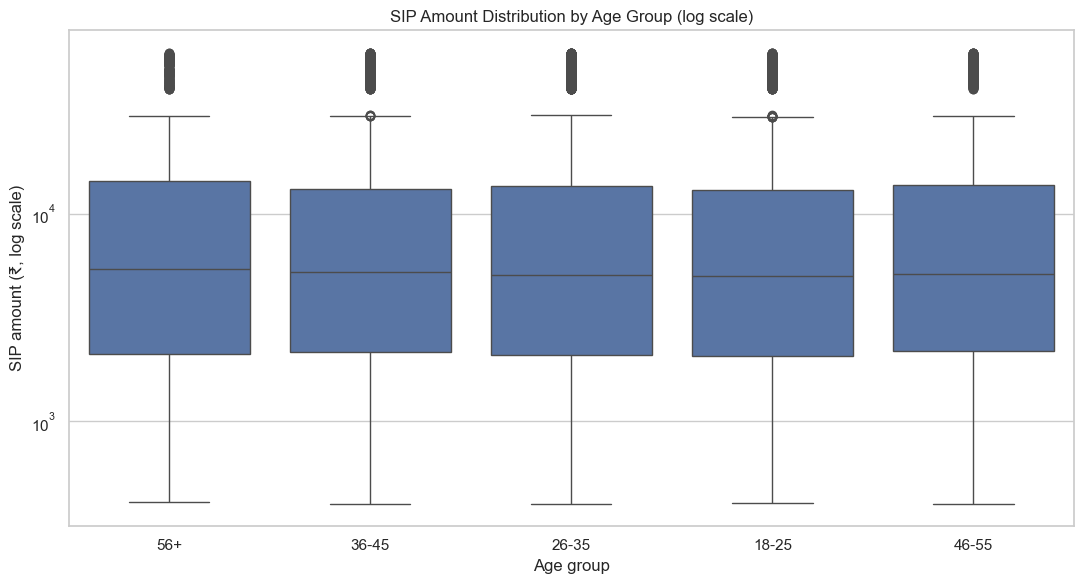

In [52]:
# Chart 10 — SIP amount box plot by age group
sip_tx = tx[tx["transaction_type"].eq("SIP")].copy()
plt.figure(figsize=(11,6))
sns.boxplot(data=sip_tx, x="age_group", y="amount_inr")
plt.yscale("log")
plt.title("SIP Amount Distribution by Age Group (log scale)")
plt.xlabel("Age group")
plt.ylabel("SIP amount (₹, log scale)")
plt.tight_layout()
plt.savefig(OUTPUTS / "10_sip_amount_by_age.png", dpi=200, bbox_inches="tight")
plt.show()


In [53]:
# Chart 11 — gender split
gender = tx["gender"].value_counts().reset_index()
gender.columns = ["gender","transactions"]
fig = px.pie(gender, names="gender", values="transactions",
             title="Investor Gender Split")
fig.show()


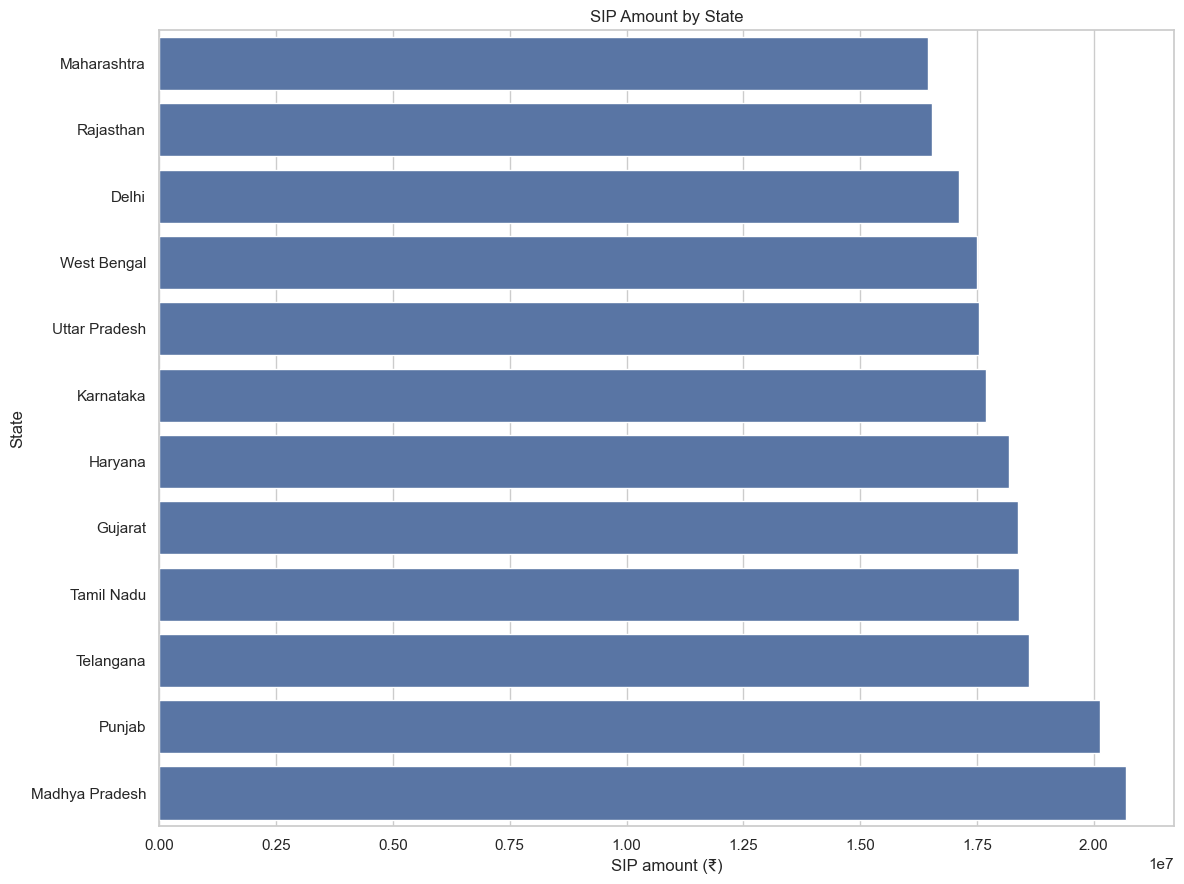

In [54]:
# Chart 12 — SIP amount by state
state_sip = sip_tx.groupby("state", as_index=False)["amount_inr"].sum().sort_values("amount_inr", ascending=True)
plt.figure(figsize=(12,9))
sns.barplot(data=state_sip, y="state", x="amount_inr")
plt.title("SIP Amount by State")
plt.xlabel("SIP amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(OUTPUTS / "12_sip_amount_by_state.png", dpi=200, bbox_inches="tight")
plt.show()


In [55]:
# Chart 13 — T30 vs B30
tier = sip_tx["city_tier"].value_counts().reset_index()
tier.columns = ["city_tier","transactions"]
fig = px.pie(tier, names="city_tier", values="transactions",
             title="SIP Transactions — T30 vs B30")
fig.show()


In [56]:
folio["month"] = pd.to_datetime(folio["month"])
folio_long = folio.melt(id_vars=["month"], var_name="folio_type", value_name="crore")
fig = px.line(folio_long, x="month", y="crore", color="folio_type",
              title="Industry Folio Count Growth",
              labels={"crore":"Folios (crore)", "month":"Month", "folio_type":"Folio type"})
fig.show()


In [57]:
# Chart 15 — total folios only with milestones
total_col = "total_folios_crore"
if total_col not in folio.columns:
    total_col = [c for c in folio.columns if "total" in c.lower() and "folio" in c.lower()][0]
f = folio.sort_values("month")
fig = px.line(f, x="month", y=total_col, title="Total Mutual Fund Folio Growth",
              labels={total_col:"Folios (crore)", "month":"Month"})
for _, r in f.iloc[::max(1, len(f)//5)].iterrows():
    fig.add_scatter(x=[r["month"]], y=[r[total_col]], mode="markers",
                    name=str(r["month"].date()))
fig.show()


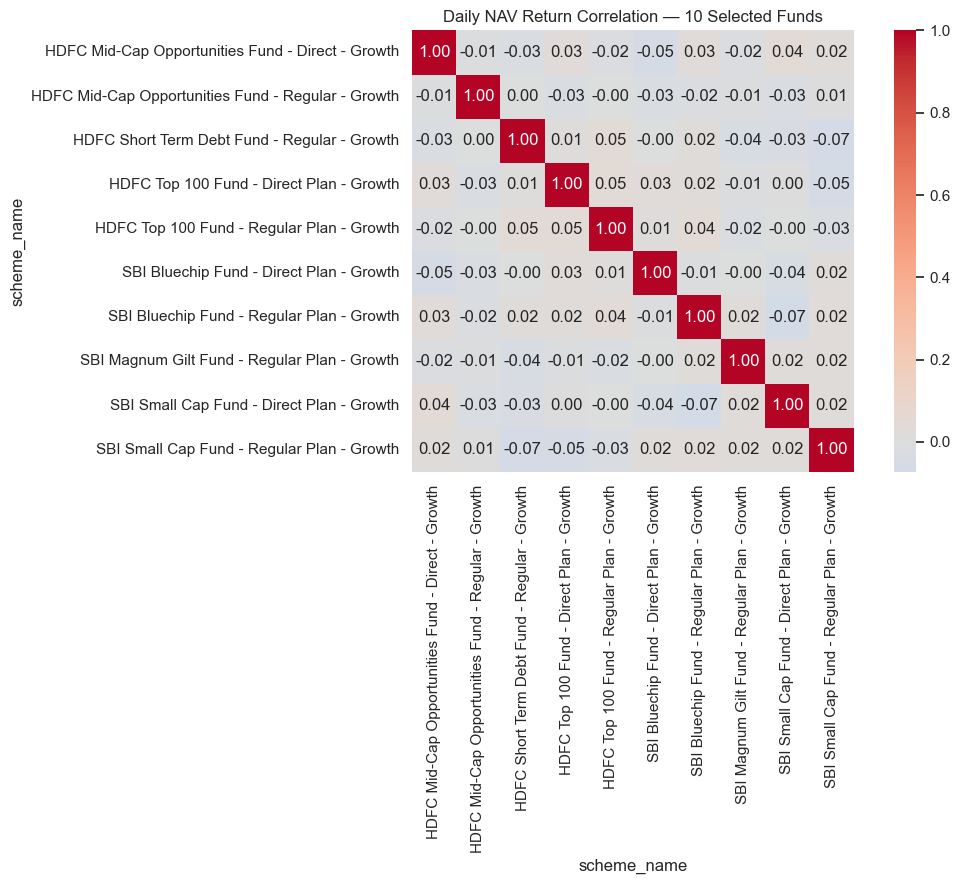

In [58]:
nav_corr = nav_plot.sort_values(["amfi_code","date"]).copy()
nav_corr["daily_return"] = nav_corr.groupby("amfi_code")["nav"].pct_change()
top10 = fund["amfi_code"].head(10).tolist()
ret10 = nav_corr[nav_corr["amfi_code"].isin(top10)].pivot(index="date", columns="scheme_name", values="daily_return")
corr = ret10.corr()

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Daily NAV Return Correlation — 10 Selected Funds")
plt.tight_layout()
plt.savefig(OUTPUTS / "15_nav_return_correlation.png", dpi=200, bbox_inches="tight")
plt.show()


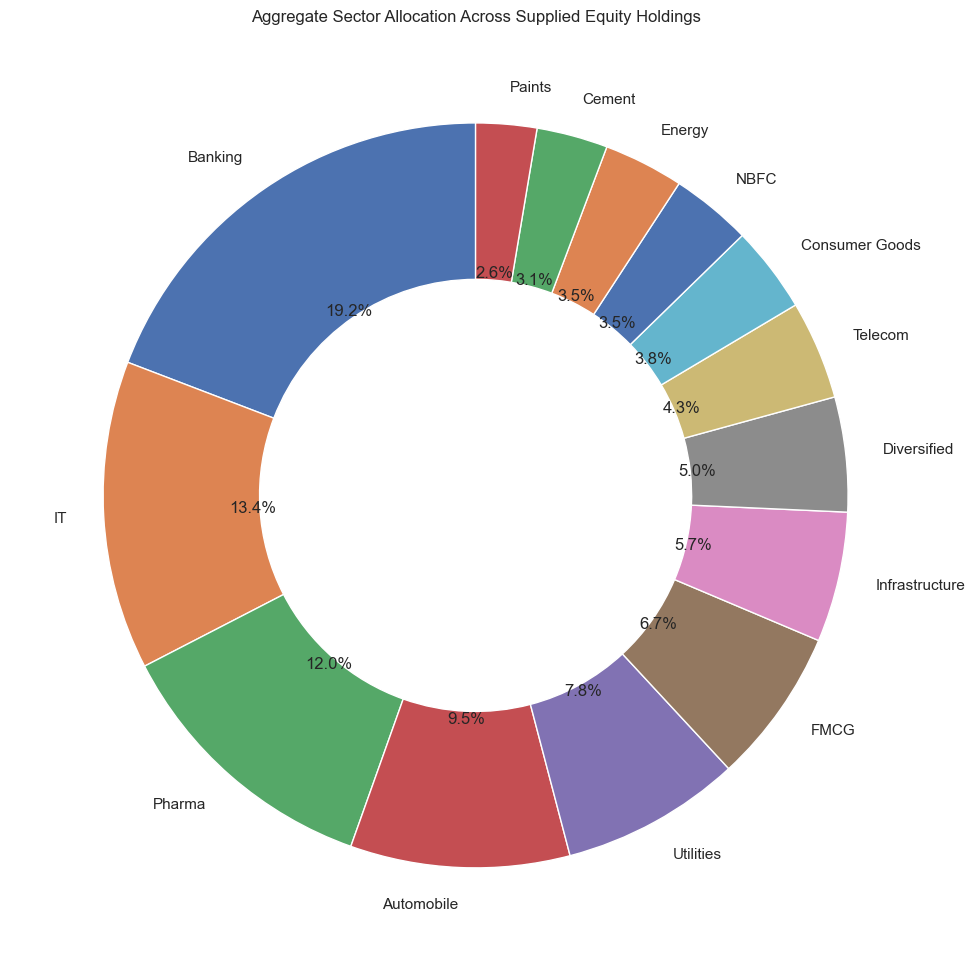

In [59]:
sector = hold.groupby("sector", as_index=False)["weight_pct"].sum().sort_values("weight_pct", ascending=False)
plt.figure(figsize=(10,10))
plt.pie(sector["weight_pct"], labels=sector["sector"], autopct="%1.1f%%", startangle=90,
        wedgeprops={"width":0.42})
plt.title("Aggregate Sector Allocation Across Supplied Equity Holdings")
plt.tight_layout()
plt.savefig(OUTPUTS / "16_sector_allocation_donut.png", dpi=200, bbox_inches="tight")
plt.show()


In [60]:
# Chart 17 — risk category distribution
risk = fund["risk_category"].value_counts().reset_index()
risk.columns = ["risk_category","schemes"]
fig = px.bar(risk, x="risk_category", y="schemes",
             title="Scheme Distribution by Risk Category")
fig.show()


In [61]:
# Chart 18 — plan distribution
plan = fund["plan"].value_counts().reset_index()
plan.columns = ["plan","schemes"]
fig = px.pie(plan, names="plan", values="schemes", title="Direct vs Regular Scheme Mix")
fig.show()


In [62]:
# Chart 19 — category distribution
cat = fund["category"].value_counts().reset_index()
cat.columns = ["category","schemes"]
fig = px.bar(cat, x="category", y="schemes", title="Scheme Count by Broad Category")
fig.show()
